<div style="padding: 1em 0.5em; color: #fff; background-color: #0969da; font-size: 1.2em;">
    Jour 4 — Analyse de compression et bilan
</div>
<div style="border-left: 2px solid #0969da; min-height: 1.5em;margin-left: 1em;padding: 1em;">
    - Rassembler précision, nombre de paramètres et latence de tous les modèles de la semaine<br>
    - Tracer le compromis efficacité/précision et situer chaque modèle sur cette frontière<br>
    - Conclure : quel modèle déployer réellement sur un appareil à faible puissance, et pourquoi<br>
</div>

#### **Votre identité**

Double-cliquez sur cette cellule et complétez, puis exécutez-la (`Maj + Entrée`).

- **Nom & prénom :** _à compléter_
- **Groupe / binôme :** _à compléter_
- **Date :** _à compléter_

<div style="height: 3px; margin: 2em 0 1.5em 0; background: linear-gradient(90deg, #0969da 0%, #0969da 55%, rgba(9,105,218,0.15) 100%);"></div>

Rassemblez tous les modèles construits cette semaine : précision, nombre de paramètres et
latence d'inférence, sur un seul graphique. C'est l'aboutissement de tout le pipeline —
combien de la précision du teacher Evo2 un modèle compressé peut-il garder, à quel prix ?

Les deux students du Jour 3 ci-dessous ont été mesurés sur les mêmes **1 000 fenêtres de validation Evo2**. La latence CPU inclut le calcul des caractéristiques et le `forward` avec un batch de taille 1. Evo2 est exclu du chemin d'inférence des deux students.

Attention à l'interprétation : l'ancien résultat est la meilleure exécution de sa grille, alors que l'Accuracy OOF est la moyenne déclarée de trois graines. Le graphique compare correctement les coûts de déploiement, mais les deux estimations de performance n'ont pas exactement le même niveau de robustesse statistique.

<img src="https://raw.githubusercontent.com/Genereux-akotenou/EEIA-bioAI-Workshop-project/main/day4/assets/overview.png"/>

In [1]:
import sys
sys.path.append("src")

import pandas as pd
from IPython.display import display
from viz import plot_efficiency_tradeoff

# Valeurs réellement mesurées dans les deux notebooks du Jour 3.
results = {
    "Jour 3 original — k=4 + MLP": {
        "accuracy": 0.8400, "f1": 0.8431, "params": 16_513,
        "feature_ms": 0.0399, "forward_ms": 0.0124, "latency_ms": 0.0523,
    },
    "Notre approche — codon/phase + KD OOF": {
        "accuracy": 0.9013, "f1": 0.9052, "params": 48_961,
        "feature_ms": 0.3879, "forward_ms": 0.0190, "latency_ms": 0.4069,
    },
}

comparison_df = pd.DataFrame(results).T.rename(columns={
    "accuracy": "Accuracy", "f1": "F1", "params": "Paramètres",
    "feature_ms": "Features (ms)", "forward_ms": "Forward CPU (ms)",
    "latency_ms": "Latence totale (ms)",
})
display(comparison_df.style.format({
    "Accuracy": "{:.2%}", "F1": "{:.2%}", "Paramètres": "{:,.0f}",
    "Features (ms)": "{:.4f}", "Forward CPU (ms)": "{:.4f}",
    "Latence totale (ms)": "{:.4f}",
}))

,Accuracy,F1,Paramètres,Features (ms),Forward CPU (ms),Latence totale (ms)
Jour 3 original — k=4 + MLP,84.00%,84.31%,"16,513",0.0399,0.0124,0.0523
Notre approche — codon/phase + KD OOF,90.13%,90.52%,"48,961",0.3879,0.0190,0.4069


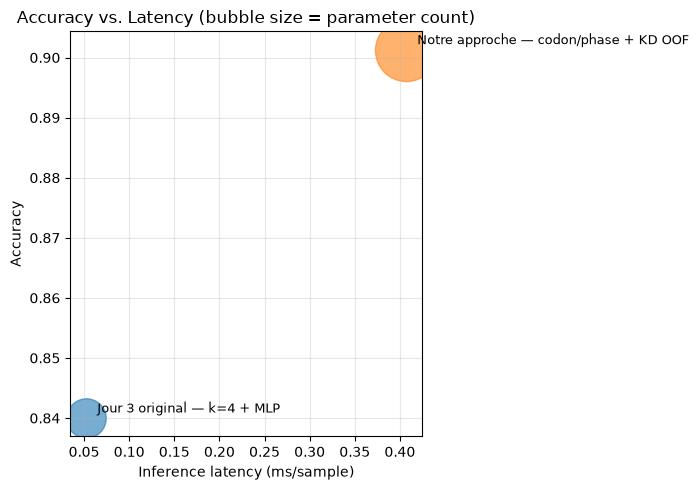

(<Figure size 700x500 with 1 Axes>,
 <Axes: title={'center': 'Accuracy vs. Latency (bubble size = parameter count)'}, xlabel='Inference latency (ms/sample)', ylabel='Accuracy'>)

In [2]:
plot_efficiency_tradeoff(results)

#### **Interprétation du compromis**

Notre student OOF n'est pas le plus rapide : ses caractéristiques codon/phase sont plus coûteuses que les seuls 4-mers. En échange, il récupère plus de six points d'Accuracy. Le temps du MLP reste très faible dans les deux cas ; l'essentiel du surcoût vient du feature engineering biologique.

In [3]:
old = results["Jour 3 original — k=4 + MLP"]
new = results["Notre approche — codon/phase + KD OOF"]

print(f"Gain d'Accuracy : {(new['accuracy'] - old['accuracy']) * 100:+.2f} points")
print(f"Multiplication des paramètres : ×{new['params'] / old['params']:.2f}")
print(f"Multiplication de la latence totale : ×{new['latency_ms'] / old['latency_ms']:.2f}")
print(f"Part du feature engineering dans la nouvelle latence : {new['feature_ms'] / new['latency_ms']:.1%}")
print("Evo2 requis à l'inférence : NON pour les deux students")

Gain d'Accuracy : +6.13 points
Multiplication des paramètres : ×2.96
Multiplication de la latence totale : ×7.78
Part du feature engineering dans la nouvelle latence : 95.3%
Evo2 requis à l'inférence : NON pour les deux students


<div style="height: 3px; margin: 2em 0 1.5em 0; background: linear-gradient(90deg, #0969da 0%, #0969da 55%, rgba(9,105,218,0.15) 100%);"></div>

#### **Discussion de bilan**

- Où se situe chaque modèle sur le compromis précision/latence/taille — et pourquoi ?
- Quelle part de la précision du teacher le student a-t-il récupérée ? Cela valait-il la perte ?
- Si vous deviez déployer un classifieur codant/non-codant sur un appareil à faible
  puissance (un séquenceur, un appareil de terrain), quel modèle choisiriez-vous
  réellement ?
- (Si vous avez fait la piste bonus) l'autoencodeur parcimonieux a-t-il trouvé des
  caractéristiques qui correspondent à quelque chose de biologiquement significatif, sans
  aucune supervision ?

Présentez votre graphique `results` et vos réponses à ces questions au groupe.

*Bloqué ? La version complète (avec des chiffres d'exemple) est dans
`solution/04_compression_analysis_and_wrapup.ipynb`.*

<div style="margin-top: 3em;">
  <div style="height: 3px; background: linear-gradient(90deg, #0969da 0%, #0969da 55%, rgba(9,105,218,0.15) 100%);"></div>
  <div style="display: flex; align-items: center; gap: 0.9em; padding: 1.1em 1em; font-size: 0.9em; color: #57606a; background-color: #f2f6fd; border-radius: 0 0 6px 6px;">
    <svg width="34" height="34" viewBox="0 0 34 34" fill="none" style="flex: 0 0 auto;">
      <path d="M9 3c0 7 16 7 16 14S9 24 9 31" stroke="#0969da" stroke-width="2" stroke-linecap="round"/>
      <path d="M25 3c0 7-16 7-16 14s16 7 16 14" stroke="#0969da" stroke-width="2" stroke-linecap="round" opacity="0.45"/>
      <circle cx="17" cy="10" r="1.8" fill="#0969da"/>
      <circle cx="17" cy="24" r="1.8" fill="#0969da"/>
    </svg>
    <div style="flex: 1 1 auto;">
      <div style="color: #0969da; font-weight: 600; letter-spacing: 0.03em;">Fin du Jour 4 &mdash; semaine termin&eacute;e</div>
      <div>Piste bonus (optionnelle) &rarr; <code>day5/bonus_sparse_autoencoder_interpretability.ipynb</code></div>
    </div>
    <div style="flex: 0 0 auto; text-align: right; border-right: 2px solid #0969da; padding-right: 0.9em;">
      <div style="font-weight: 600; color: #24292f;">EEIA &middot; bioAI Workshop</div>
      <div style="font-size: 0.85em;">Semaine 4 &mdash; De l'ADN aux mod&egrave;les compress&eacute;s</div>
    </div>
  </div>
</div>